# Testing LOSD
### Bevölkerung nach Religion, Herkunft und Statistischer Zone

Wirtschaftliche Wohnbevölkerung nach Religion, Herkunft, allen administrativen Einteilungen der Stadt Zürich und Jahr, seit 1993.

- INT: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_jahr_statzone_herkunft_konfession_od3161
- PROD: https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_statzone_herkunft_konfession_od3161

Datum: 15.03.2024




### Importiere die notwendigen Packages

In [2]:
#%pip install altair datetime folium geopandas io requests matplotlib numpy pandas seaborn plotly
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())


6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)


In [3]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotly.express as px
import requests
import seaborn as sns

In [4]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln

In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [9]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

**BITTE HIER ANPASSEN**

In [10]:
#speichere die variable global, damit ich sie später verwenden kann, wenn ich grafiken mit diesem namen speichere.
losd_package_name = "bev316od3161"
package_name = "bev_bestand_jahr_statzone_herkunft_konfession_od3161"

In [11]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV316OD3161"    
    , datums_attr = ['StichtagDatJahr']
    )


fp lautet:https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_statzone_herkunft_konfession_od3161/download/BEV316OD3161.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_statzone_herkunft_konfession_od3161 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_bestand_jahr_statzone_herkunft_konfession_od3161 

data_source: web


In [12]:
data2betested.head(2)

,StichtagDatJahr,StatZoneSort,StatZoneLang,QuarSort,QuarLang,KreisSort,HerkunftSort,HerkunftCd,HerkunftLang,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,AnzBestWir
0,1993-01-01,1,Zähringerstrasse,11,Rathaus,1,1,1,Schweizer*in,1,1,Evangelisch-Reformiert,157
1,1993-01-01,1,Zähringerstrasse,11,Rathaus,1,1,1,Schweizer*in,2,2,Römisch-Katholisch,122


Berechne weitere Attribute falls notwendig

-------------------------------------------------------

In [13]:
data2betested = (
    data2betested
    .copy()
    .assign(

        ZEIT_LANG = lambda x: x.StichtagDatJahr,
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
        BEW = lambda x: x.AnzBestWir.astype(int),
        RAUM_LANG = lambda x: x.StatZoneLang,
        RAUM_CODE = lambda x: x.StatZoneSort
       #StichtagDatJahr = lambda x: x.ZEIT_LANG.apply(convert_to_datetime),
        #StichtagDatJahr_str = lambda x: x.ZEIT_LANG.astype(str),
        #Jahr_nbr = lambda x: x.ZEIT_CODE.str[-4:].astype(int),    
        #RAUM_my_sort = lambda x: x.ZEIT_CODE.str[1:].astype(int),

    )
    .sort_values('ZEIT_LANG', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr     datetime64[ns]
StatZoneSort                 int64
StatZoneLang                object
QuarSort                     int64
QuarLang                    object
KreisSort                    int64
HerkunftSort                 int64
HerkunftCd                   int64
HerkunftLang                object
Kon2AggSort_noDM             int64
Kon2AggCd_noDM               int64
Kon2AggLang_noDM            object
AnzBestWir                   int64
ZEIT_LANG           datetime64[ns]
Jahr                datetime64[ns]
Jahr_end            datetime64[ns]
Jahr_nbr                     int32
BEW                          int32
RAUM_LANG                   object
RAUM_CODE                    int64
dtype: object

Minimales und maximales Jahr im Datensatz

In [14]:
data_max_date = str(max(data2betested.StichtagDatJahr).year)
data_min_date = str(min(data2betested.StichtagDatJahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


Zeitbereich aus den Daten:

In [15]:
data_max_date = str(max(data2betested.Jahr_nbr))

try:
    if min(data2betested.Jahr_nbr) < 1678:
        data_min_date="1688"
    else:
        data_min_date = str(min(data2betested.Jahr_nbr))
except ValueError:
    print("Fehler...")

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")


Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


### Einfache Datentests

In [16]:
data2betested.head(2).T

,40577,39733
StichtagDatJahr,2024-01-01 00:00:00,2024-01-01 00:00:00
StatZoneSort,260,92
StatZoneLang,Probsteistrasse,Berufsschulen
QuarSort,123,51
QuarLang,Hirzenbach,Gewerbeschule
KreisSort,12,5
HerkunftSort,2,1
HerkunftCd,2,1
HerkunftLang,Ausländer*in,Schweizer*in
Kon2AggSort_noDM,3,2


In [17]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 40578 entries, 40577 to 0
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   StichtagDatJahr   40578 non-null  datetime64[ns]
 1   StatZoneSort      40578 non-null  int64         
 2   StatZoneLang      40578 non-null  object        
 3   QuarSort          40578 non-null  int64         
 4   QuarLang          40578 non-null  object        
 5   KreisSort         40578 non-null  int64         
 6   HerkunftSort      40578 non-null  int64         
 7   HerkunftCd        40578 non-null  int64         
 8   HerkunftLang      40578 non-null  object        
 9   Kon2AggSort_noDM  40578 non-null  int64         
 10  Kon2AggCd_noDM    40578 non-null  int64         
 11  Kon2AggLang_noDM  40578 non-null  object        
 12  AnzBestWir        40578 non-null  int64         
 13  ZEIT_LANG         40578 non-null  datetime64[ns]
 14  Jahr              40578 non

In [18]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 40,578 rows (observations) and 20 columns (variables).
There seem to be 0 exact duplicates in the data.


Welches sind die Quartiere ohne Werte bei BEW?

In [19]:
data2betested[np.isnan(data2betested.BEW)]

,StichtagDatJahr,StatZoneSort,StatZoneLang,QuarSort,QuarLang,KreisSort,HerkunftSort,...,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW,RAUM_LANG,RAUM_CODE


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [20]:
data2betested = data2betested.set_index("StichtagDatJahr") 
data2betested = data2betested.sort_index()

In [21]:
data2betested.index.year.unique()


Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [22]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [23]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,StatZoneSort,QuarSort,KreisSort,HerkunftSort,HerkunftCd,Kon2AggSort_noDM,Kon2AggCd_noDM,AnzBestWir,Jahr_nbr,BEW,RAUM_CODE
count,"40,578","40,578","40,578","40,578","40,578","40,578","40,578","40,578","40,578","40,578","40,578"
mean,133,69,7,1,1,2,2,308,"2,009",308,133
std,75,34,3,1,1,1,1,278,9,278,75
min,1,11,1,1,1,1,1,0,"1,993",0,1
25%,67,34,3,1,1,1,1,78,"2,001",78,67
50%,133,72,7,1,1,2,2,248,"2,009",248,133
75%,198,101,10,2,2,3,3,450,"2,017",450,198
max,260,123,12,2,2,3,3,"2,264","2,024","2,264",260


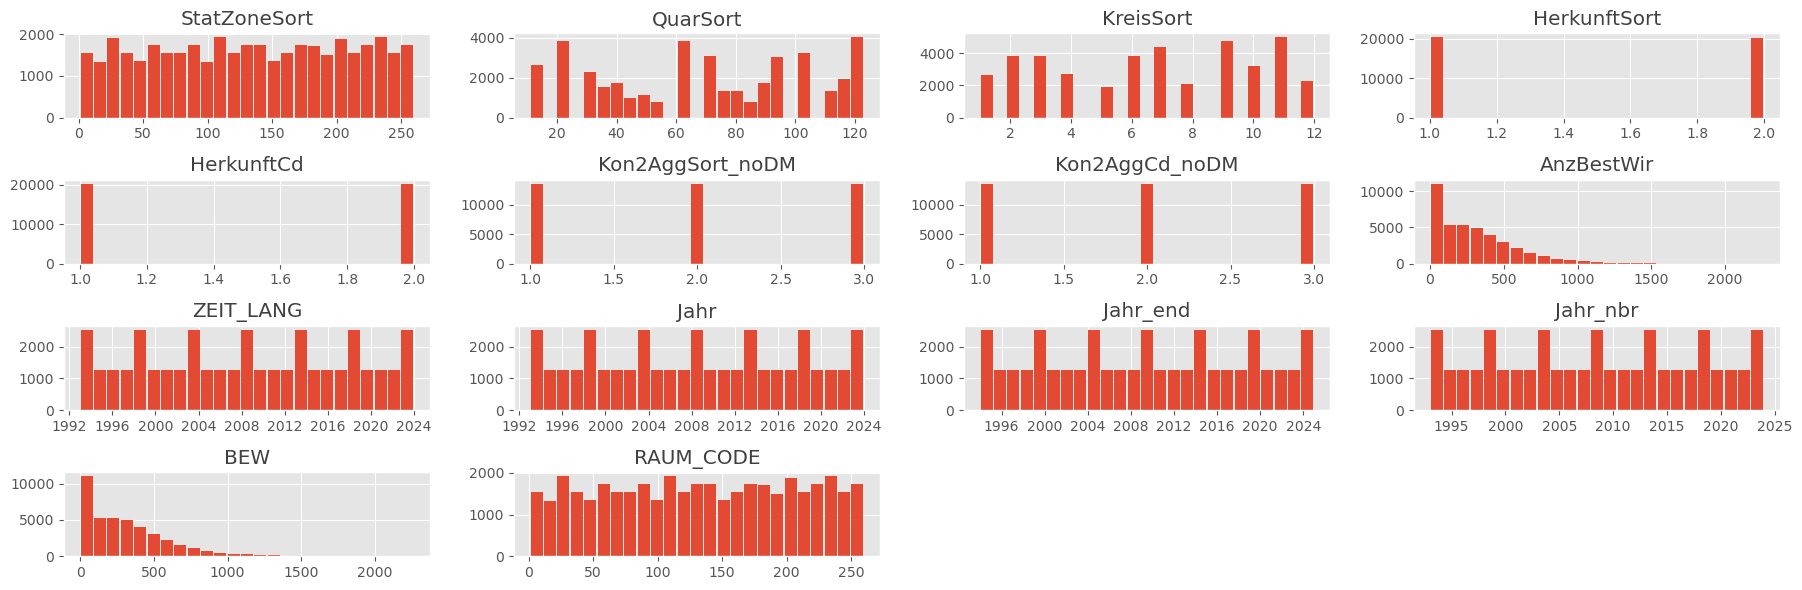

In [24]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [25]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StatZoneSort,StatZoneLang,QuarSort,QuarLang,KreisSort,HerkunftSort,HerkunftCd,...,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW,RAUM_LANG,RAUM_CODE
StichtagDatJahr,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [26]:
data2betested.isnull().sum()

StatZoneSort        0
StatZoneLang        0
QuarSort            0
QuarLang            0
KreisSort           0
HerkunftSort        0
HerkunftCd          0
HerkunftLang        0
Kon2AggSort_noDM    0
Kon2AggCd_noDM      0
Kon2AggLang_noDM    0
AnzBestWir          0
ZEIT_LANG           0
Jahr                0
Jahr_end            0
Jahr_nbr            0
BEW                 0
RAUM_LANG           0
RAUM_CODE           0
dtype: int64

In [27]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [28]:
data2betested.columns

Index(['StatZoneSort', 'StatZoneLang', 'QuarSort', 'QuarLang', 'KreisSort', 'HerkunftSort',
       'HerkunftCd', 'HerkunftLang', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM',
       'AnzBestWir', 'ZEIT_LANG', 'Jahr', 'Jahr_end', 'Jahr_nbr', 'BEW', 'RAUM_LANG', 'RAUM_CODE'],
      dtype='object')

In [29]:
agg_Herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftSort', 'HerkunftCd', 'HerkunftLang',]) \
    .agg(sum_AnzBestWir=('BEW', 'sum')) \
    .sort_values(['HerkunftSort'], ascending=[False]) 
agg_Herk.reset_index().head(5)

,HerkunftSort,HerkunftCd,HerkunftLang,sum_AnzBestWir
0,2,2,Ausländer*in,3847793
1,1,1,Schweizer*in,8661886


In [30]:
agg_Konf = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr','Jahr_nbr', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM']) \
    .agg(sum_AnzBestWir=('BEW', 'sum')) \
    .sort_values(['Jahr_nbr','Kon2AggSort_noDM'], ascending=[False, True]) 
agg_Konf.reset_index().head(5)

,Jahr,Jahr_nbr,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,sum_AnzBestWir
0,2024-01-01,2024,1,1,Evangelisch-Reformiert,71413
1,2024-01-01,2024,2,2,Römisch-Katholisch,93622
2,2024-01-01,2024,3,3,"Andere, ohne, unbekannt",283629
3,2023-01-01,2023,1,1,Evangelisch-Reformiert,74269
4,2023-01-01,2023,2,2,Römisch-Katholisch,97639


### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [31]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StatZoneSort,StatZoneLang,QuarSort,QuarLang,KreisSort,HerkunftSort,HerkunftCd,...,ZEIT_LANG,Jahr,Jahr_end,Jahr_nbr,BEW,RAUM_LANG,RAUM_CODE
StichtagDatJahr,,,,,,,,,,,,,,,
2024-01-01,1,Zähringerstrasse,11,Rathaus,1,2,2,...,2024-01-01,2024-01-01,2024-12-31,2024,11,Zähringerstrasse,1
2024-01-01,17,Selnaustrasse,14,City,1,2,2,...,2024-01-01,2024-01-01,2024-12-31,2024,149,Selnaustrasse,17


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Wohnbevölkerung seit ...

In [32]:
myAgg1 = agg_Rel

myAgg1.reset_index().head(1)

NameError: name 'agg_Rel' is not defined

In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('sum_AnzBestWir>3')
    , x = 'Jahr:T'
    , y = 'sum_AnzBestWir:Q'
    , x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    , warning_status  = "ignore"
    , category='Kon2AggLang_noDM'
    , category_beschriftung='legende:'
    , myTitle="Bevölkerungsentwicklung nach Konfession, seit "+data_min_date    
)
grafik1

alt.LayerChart(...)

##### Stacked Bar Chart

In [ ]:
myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'Jahr', 'Jahr_end', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=True) 

myAggBar.reset_index().head(3)

,Kon2AggSort_noDM,Kon2AggCd_noDM,Kon2AggLang_noDM,Jahr,Jahr_end,Jahr_nbr,sum_WBev
0,1,1,Evangelisch-Reformiert,1993-01-01,1993-12-31,1993,129157
1,3,3,"Andere, ohne, unbekannt",1993-01-01,1993-12-31,1993,97129
2,2,2,Römisch-Katholisch,1993-01-01,1993-12-31,1993,134612


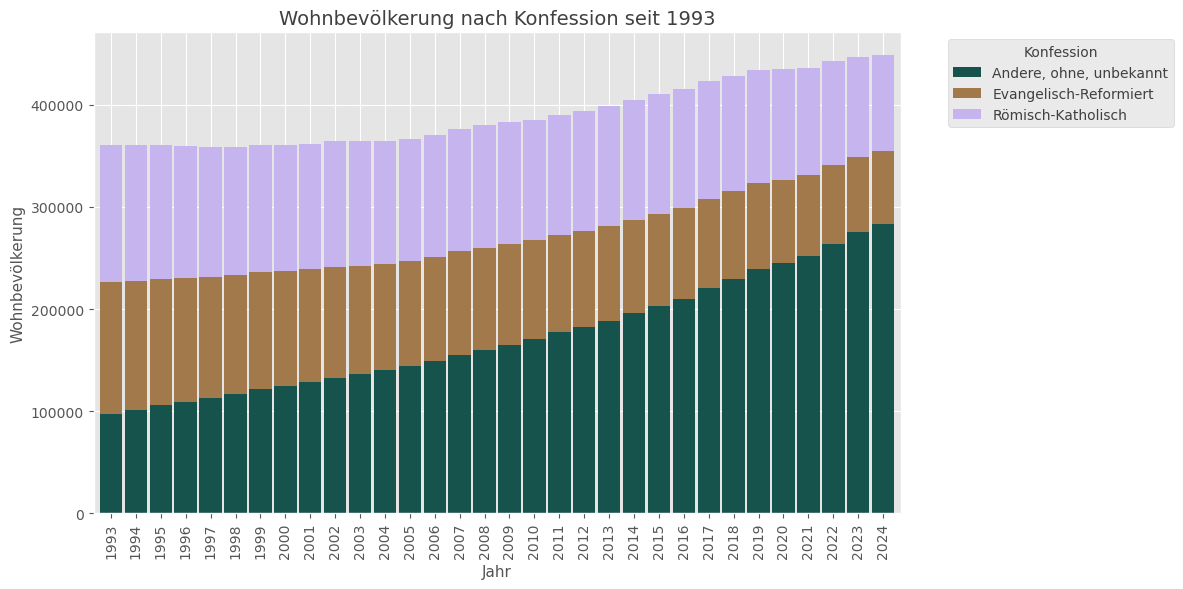

In [ ]:
# Daten vorbereiten

data = myAggBar.query("sum_WBev > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='Kon2AggLang_noDM', values='sum_WBev').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Wohnbevölkerung nach Konfession seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Wohnbevölkerung', fontsize=11)

# Legende anpassen
plt.legend(title='Konfession', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

In [ ]:
data2betested.columns

Index(['StatZoneSort', 'StatZoneLang', 'QuarSort', 'QuarLang', 'KreisSort', 'HerkunftSort',
       'HerkunftCd', 'HerkunftLang', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM',
       'AnzBestWir', 'ZEIT_LANG', 'Jahr', 'Jahr_end', 'Jahr_nbr', 'BEW', 'RAUM_LANG', 'RAUM_CODE'],
      dtype='object')

#### Faced Grids

In [ ]:
myFG = data2betested.query('HerkunftLang !="Ausland"')\
    .groupby(['StichtagDatJahr', 'QuarSort', 'QuarLang','Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM', 'HerkunftCd']) \
    .agg(sum_WBev=('BEW', 'sum')) \
    .sort_values('QuarSort', ascending=True) 
myFG

sum_WBev
StichtagDatJahr QuarSort QuarLang   Kon2AggSort_noDM Kon2AggCd_noDM Kon2AggLang_noDM        HerkunftCd          
1993-01-01      11       Rathaus    1                1              Evangelisch-Reformiert  1               1064
2010-01-01      11       Rathaus    2                2              Römisch-Katholisch      2                226
                                    3                3              Andere, ohne, unbekannt 1                851
                                                                                            2                574
1996-01-01      11       Rathaus    1                1              Evangelisch-Reformiert  2                 51
...                                                                                                          ...
2012-01-01      123      Hirzenbach 3                3              Andere, ohne, unbekannt 2               2318
                                                                                            1               3167
                                    2                2              Römisch-Katholisch      2               1517
2014-01-01      123      Hirzenbach 1                1              Evangelisch-Reformiert  1               1980
2024-01-01      123      Hirzenbach 3                3              Andere, ohne, unbekannt 2               3339

[6528 rows x 1 columns]

In [ ]:
#data2betested.columns
data2betested.sort_values(by=['Jahr_nbr', 'RAUM_CODE'], ascending=[True, True]).tail(6).T
#data2betested.dtypes

StichtagDatJahr,2024-01-01,2024-01-01,2024-01-01,2024-01-01,2024-01-01,2024-01-01
StatZoneSort,260,260,260,260,260,260
StatZoneLang,Probsteistrasse,Probsteistrasse,Probsteistrasse,Probsteistrasse,Probsteistrasse,Probsteistrasse
QuarSort,123,123,123,123,123,123
QuarLang,Hirzenbach,Hirzenbach,Hirzenbach,Hirzenbach,Hirzenbach,Hirzenbach
KreisSort,12,12,12,12,12,12
HerkunftSort,2,2,1,1,1,2
HerkunftCd,2,2,1,1,1,2
HerkunftLang,Ausländer*in,Ausländer*in,Schweizer*in,Schweizer*in,Schweizer*in,Ausländer*in
Kon2AggSort_noDM,2,1,1,2,3,3
Kon2AggCd_noDM,2,1,1,2,3,3


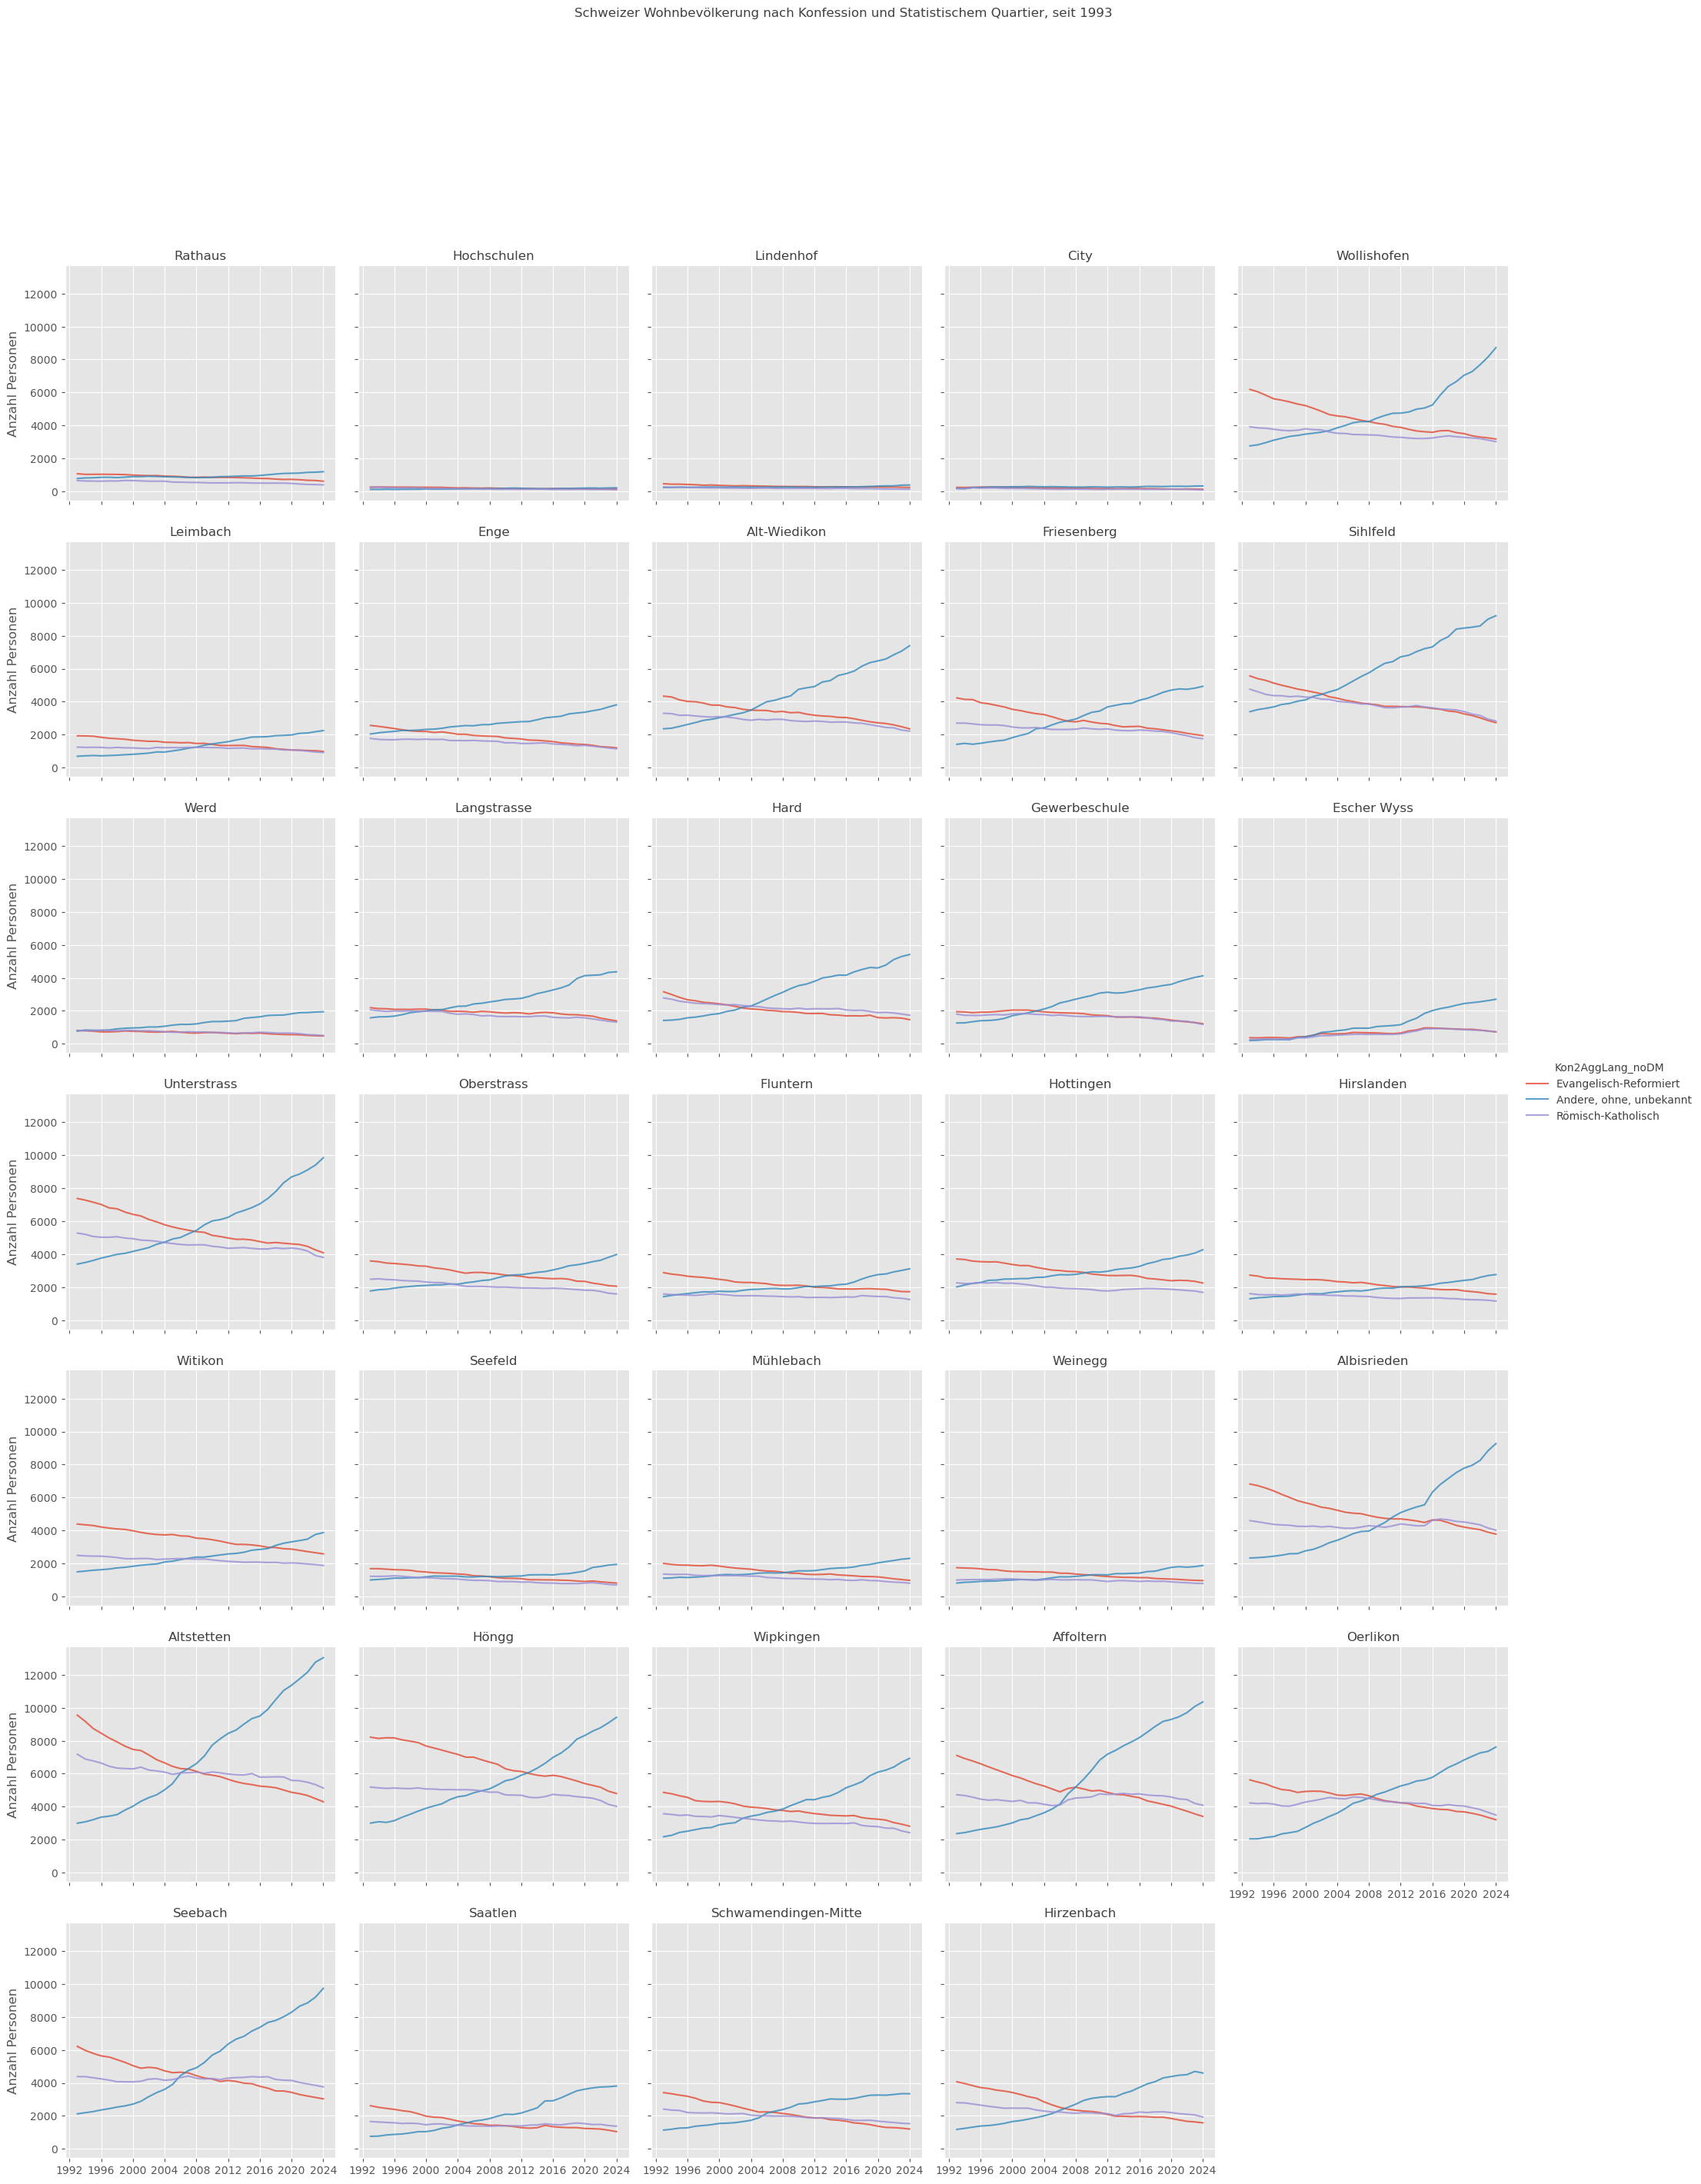

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.query('HerkunftCd == 1').reset_index().sort_values('QuarSort', ascending=True)
    ,col = "QuarLang"
    ,hue = "Kon2AggLang_noDM"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Schweizer Wohnbevölkerung nach Konfession und Statistischem Quartier, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

In [ ]:
myFG2 = data2betested.query('HerkunftLang !="Ausland"')\
    .groupby(['StichtagDatJahr', 'RAUM_LANG', 'RAUM_CODE', 'QuarSort', 'QuarLang','Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM' ]) \
    .agg(sum_WBev=('BEW', 'sum')) \
    .sort_values('RAUM_CODE', ascending=True) 
myFG2

sum_WBev
StichtagDatJahr RAUM_LANG        RAUM_CODE QuarSort QuarLang   Kon2AggSort_noDM Kon2AggCd_noDM Kon2AggLang_noDM                 
2024-01-01      Zähringerstrasse 1         11       Rathaus    3                3              Andere, ohne, unbekannt       401
2007-01-01      Zähringerstrasse 1         11       Rathaus    1                1              Evangelisch-Reformiert        130
2001-01-01      Zähringerstrasse 1         11       Rathaus    1                1              Evangelisch-Reformiert        138
                                                               2                2              Römisch-Katholisch            179
                                                               3                3              Andere, ohne, unbekannt       220
...                                                                                                                          ...
2011-01-01      Probsteistrasse  260       123      Hirzenbach 2                2              Römisch-Katholisch            622
                                                               1                1              Evangelisch-Reformiert        623
2003-01-01      Probsteistrasse  260       123      Hirzenbach 1                1              Evangelisch-Reformiert        750
                                                               3                3              Andere, ohne, unbekannt       462
2010-01-01      Probsteistrasse  260       123      Hirzenbach 2                2              Römisch-Katholisch            634

[20331 rows x 1 columns]

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('RAUM_CODE', ascending=True)
    ,col = "RAUM_LANG"
    ,hue = "Kon2AggLang_noDM"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,palette = zuericolors_qual12
    ,myTitle="Wohnbevölkerung nach Konfession und Statistischer Zone, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

NameError: name 'mypy_dv' is not defined

#### Treemaps

**Funktion zum einfärben**

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
auspraegungen = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
# z.B. zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_qual12+zuericolors_div9ntr
verfügbare_farben_zuericolors = zuericolors_qual12da+zuericolors_qual12br+zuericolors_qual12+zuericolors_qual12+zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(auspraegungen):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Rathaus': '#0017BF', 'City': '#0072D7', 'Hochschulen': '#00A5D2', 'Lindenhof': '#5E359A', 'Leimbach': '#BA0062', 'Wollishofen': '#DA5563', 'Sihlfeld': '#00615D', 'Enge': '#00770F', 'Alt-Wiedikon': '#7BA600', 'Friesenberg': '#7B4100', 'Hottingen': '#DC5500', 'Unterstrass': '#DA9C00', 'Hard': '#5D4BFE', 'Werd': '#4AA9FF', 'Langstrasse': '#55FFFF', 'Escher Wyss': '#986AD5', 'Gewerbeschule': '#FC4C99', 'Oberstrass': '#FF919A', 'Fluntern': '#349894', 'Altstetten': '#44B14A', 'Witikon': '#B7E14E', 'Hirslanden': '#B97624', 'Weinegg': '#FF7231', 'Seefeld': '#FFD736', 'Mühlebach': '#3431DE', 'Höngg': '#0A8DF6', 'Albisrieden': '#23C3F1', 'Seebach': '#7B4FB7', 'Wipkingen': '#DB247D', 'Oerlikon': '#FB737E', 'Affoltern': '#007C78', 'Hirzenbach': '#1F9E31', 'Saatlen': '#99C32E', 'Schwamendingen-Mitte': '#9A5B01'}


##### Wohnbevölkerung nach Konfession, Herkunft und räumlichen Einheiten

In [ ]:
data2betested.columns

Index(['StatZoneSort', 'StatZoneLang', 'QuarSort', 'QuarLang', 'KreisSort', 'HerkunftSort',
       'HerkunftCd', 'HerkunftLang', 'Kon2AggSort_noDM', 'Kon2AggCd_noDM', 'Kon2AggLang_noDM',
       'AnzBestWir', 'ZEIT_LANG', 'Jahr', 'Jahr_end', 'Jahr_nbr', 'BEW', 'RAUM_LANG', 'RAUM_CODE'],
      dtype='object')

In [ ]:
#myTM1 = data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2024)].reset_index()  \
myTM1 = data2betested.loc[data_max_date].reset_index()  \
    .groupby(['StichtagDatJahr', 'Jahr_nbr','QuarLang', 'KreisSort', 'HerkunftLang', 'Kon2AggLang_noDM']) \
    .agg(AnzBestWir=('BEW', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 
myTM1.reset_index().head(2)

,StichtagDatJahr,Jahr_nbr,QuarLang,KreisSort,HerkunftLang,Kon2AggLang_noDM,AnzBestWir
0,2024-01-01,2024,Altstetten,9,Schweizer*in,"Andere, ohne, unbekannt",13040
1,2024-01-01,2024,Affoltern,11,Schweizer*in,"Andere, ohne, unbekannt",10351


In [ ]:
treeMap1= mypy_dv.plot_px_treemap(
    data=myTM1.reset_index()
    ,levels=['Jahr_nbr', 'KreisSort','QuarLang', 'HerkunftLang', 'Kon2AggLang_noDM']
    ,values="AnzBestWir"
    ,color="Kon2AggLang_noDM"
    #, color_continuous_scale='Blues'
    # farben_dict_zc
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wohnbevölkerung nach Konfession, Herkunft und Raum, "+str(myTM1.reset_index().Jahr_nbr.min()) 
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000014E5B5DF490>, 'Jahr_nbr', 'KreisSort', 'QuarLang', 'HerkunftLang', 'Kon2AggLang_noDM']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

- Sharepoint SASA: [Sharepoint](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=481&e=2hyslq)


--------------